In [19]:
import pandas as pd
import protfasta
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


# Control variables

In [3]:
# Proteome fasta from uniprot
proteome_file_path = "../data/s_cer_proteome_UP000002311_559292.fasta"

# Synthetics activity scores
synthetics_file_path = "../data/synthetics_DF.csv"

# Prefix to affend to save generated figures
output_path = "../output/"

# Helper function

Function to go from fasta to dataframe of sequences with specified window size and spacing.

In [4]:
def makeTilingDF(inputfilename, window_size=39, window_spacing=1, AAs=['W', 'F', 'Y', 'M', 'L', 'Q']):
    """
    Extracts tiling windows of a specified size and spacing from protein sequences in a FASTA file.

    Parameters:
    -----------
    inputfilename : str
        Path to the input FASTA file containing protein sequences.
    window_size : int, optional
        Size of the tiling window (default is 39).
    window_spacing : int, optional
        Spacing between consecutive tiling windows (default is 1).
    AAs : list of str, optional
        List of amino acids to filter for in the sequences (default is ['W', 'F', 'Y', 'M', 'L', 'Q']).

    Returns:
    --------
    pandas.DataFrame
        A DataFrame containing tiling windows with the following columns:
        - 'ProteinWindowSeq': The sequence of the tiling window.
        - 'GeneName': The name of the protein/gene.
        - 'StartPosition': The start position of the window in the sequence.
        - 'EndPosition': The end position of the window in the sequence.
        - Columns for counts of each amino acid in `AAs` and net charge ('Charge').

    Notes:
    ------
    - The net charge is calculated as: Charge = (K + R) - (D + E).

    Example:
    --------
    df = makeTilingDF("../data/proteome.fasta", window_size=50, window_spacing=5, AAs=['A', 'T', 'G'])
    """
    import re
    import numpy as np

    print("Creating new Tiling DF")     
    ProteomeDict = protfasta.read_fasta(inputfilename, return_list=False, 
                                        invalid_sequence_action='ignore',
                                        duplicate_record_action='ignore',
                                        duplicate_sequence_action='ignore',
                                        expect_unique_header=False)
    
    TilingWindows, ProteinNames, Npos, Cpos = [], [], [], []

    # Generate tiling windows
    for gene in ProteomeDict:
        line = ProteomeDict[gene]
        if len(line) < window_size:
            subset = line
            Npos.append(0), Cpos.append(len(line))
            TilingWindows.append(subset)
            ProteinNames.append(gene)
        else:
            for i in np.arange(0, len(line) - window_size + window_spacing, window_spacing):
                subset = line[i:i + window_size]
                Npos.append(i), Cpos.append(i + len(subset))
                TilingWindows.append(subset)
                ProteinNames.append(gene)

    print("Window Size = %i  and Window spacing = %i" % (window_size, window_spacing))
    print("Number of Tiling Windows: %i" % len(TilingWindows))

    # Create DataFrame
    ProteomeDF = pd.DataFrame({'ProteinWindowSeq': TilingWindows, 'GeneName': ProteinNames,
                               'StartPosition': Npos, 'EndPosition': Cpos})
    
    AAs = AAs + ['K', 'R', 'D', 'E']
    # Count amino acids
    for aa in AAs:
        ProteomeDF[aa] = ProteomeDF["ProteinWindowSeq"].str.count(aa)
    
    # Compute net charge
    ProteomeDF['Charge'] = ProteomeDF['K'] + ProteomeDF['R'] - ProteomeDF['D'] - ProteomeDF['E']

    return ProteomeDF


# Tiling the S. Cer Proteome

## Plan for Tiling Proteome with 40AA Windows

- **Goal**: Since the synthetic sequences are 40 amino acids (AA), I want to tile the proteome in 40AA windows.  
- **Problem**: Protein lengths are rarely divisible by 40.  

### Example (protein length = 130 AA)
- Desired output:  
  `1–40, 40–80, 80–120, 90–130`

### Implementation Steps

1. **tiled_proteome_unprocessed** → Tile proteome at 40AA with window spacing of 40AA  
   - Example:  
     `1–40, 40–80, 80–120, 120–130`

2. **tiled_proteome_step1** → Tile proteome at 40AA with window spacing of 1AA  
   - This table serves as an intermediate resource to fill in the missing C-terminal segments.  
   - Example:  
     `1–40, 2–41, 3–42, ..., 89–129, 90–130, 91–130, ..., 120–130, ..., 129–130`

3. **tiled_proteome_merged** → Merge `tiled_proteome_unprocessed` and `tiled_proteome_step1` on the *End* position  
   - Example:  
     `1–40, 40–80, 80–120, 89–130, 90–130, 91–130, ..., 120–130, ..., 129–130`

4. **tiled_proteome_final** → Remove intervals where length ≠ 40  
   - Final result!  
     `1–40, 40–80, 80–120, 90–130` 

In [5]:
# Step1: Tile the proteome data into window size 40, spaced every 40AA
tiled_proteome_unprocessed = makeTilingDF(proteome_file_path, window_size=40, window_spacing=40)
tiled_proteome_unprocessed

Creating new Tiling DF
Window Size = 40  and Window spacing = 40
Number of Tiling Windows: 76322


,ProteinWindowSeq,GeneName,StartPosition,EndPosition,W,F,Y,M,L,Q,K,R,D,E,Charge
0,MAAQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAK,sp|P04650|RL39_YEAST Large ribosomal subunit p...,0,40,1,1,1,2,2,4,7,5,0,0,12
1,RRNWRRTKMNI,sp|P04650|RL39_YEAST Large ribosomal subunit p...,40,51,1,0,0,1,0,0,1,4,0,0,5
2,MGVHSFWDIAGPTARPVRLESLEDKRMAVDASIWIYQFLK,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,0,40,2,2,1,2,3,1,2,3,3,2,0
3,AVRDQEGNAVKNSHITGFFRRICKLLYFGIRPVFVFDGGV,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,40,80,0,5,1,0,2,1,2,4,2,1,3
4,PVLKRETIRQRKERRQGKRESAKSTARKLLALQLQNGSND,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,80,120,0,0,0,0,5,4,5,7,1,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76317,NNDNKEDSEHICPDRTIANHEGPKDDFEAPVVMPSPNDIQ,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,80,120,0,1,0,1,0,1,2,1,6,4,-7
76318,FLLEVEYKGDLLVTIGADLVLNYPVEKFMTLPVKLSISDI,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,120,160,0,2,2,1,8,0,3,0,3,3,-3
76319,GLHSLCIVACLSKQLFLSFLCDVSDPALDDNQTVLDPKGP,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,160,200,0,2,0,0,8,2,2,0,5,0,-3
76320,ILAATKPLERISIVRSMKIETEIGEQYQGQGSVLRSVGEL,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,200,240,0,0,1,1,4,3,2,3,0,5,0


In [6]:
# Tile proteome at 40 AA with window spacing of 1 AA
tiled_proteome_step_1 = makeTilingDF(proteome_file_path, window_size=40, window_spacing=1)
tiled_proteome_step_1

Creating new Tiling DF
Window Size = 40  and Window spacing = 1
Number of Tiling Windows: 2701803


,ProteinWindowSeq,GeneName,StartPosition,EndPosition,W,F,Y,M,L,Q,K,R,D,E,Charge
0,MAAQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAK,sp|P04650|RL39_YEAST Large ribosomal subunit p...,0,40,1,1,1,2,2,4,7,5,0,0,12
1,AAQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAKR,sp|P04650|RL39_YEAST Large ribosomal subunit p...,1,41,1,1,1,1,2,4,7,6,0,0,13
2,AQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAKRR,sp|P04650|RL39_YEAST Large ribosomal subunit p...,2,42,1,1,1,1,2,4,7,7,0,0,14
3,QKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAKRRN,sp|P04650|RL39_YEAST Large ribosomal subunit p...,3,43,1,1,1,1,2,4,7,7,0,0,14
4,KSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAKRRNW,sp|P04650|RL39_YEAST Large ribosomal subunit p...,4,44,2,1,1,1,2,3,7,7,0,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701798,QGQGSVLRSVGELEQFLFTIFKDFLRKELAWPSWINLDFN,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,227,267,2,5,0,0,6,3,2,2,2,3,-1
2701799,GQGSVLRSVGELEQFLFTIFKDFLRKELAWPSWINLDFND,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,228,268,2,5,0,0,6,2,2,2,3,3,-2
2701800,QGSVLRSVGELEQFLFTIFKDFLRKELAWPSWINLDFNDG,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,229,269,2,5,0,0,6,2,2,2,3,3,-2
2701801,GSVLRSVGELEQFLFTIFKDFLRKELAWPSWINLDFNDGD,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,230,270,2,5,0,0,6,1,2,2,4,3,-3


In [7]:
# Per gene, Merge `tiled_proteome_unprocessed` and `tiled_proteome_step1` on the *End* position  
tiled_proteome = pd.merge(tiled_proteome_unprocessed[["GeneName", "EndPosition"]], tiled_proteome_step_1, on = ["GeneName", "EndPosition"])
tiled_proteome

,GeneName,EndPosition,ProteinWindowSeq,StartPosition,W,F,Y,M,L,Q,K,R,D,E,Charge
0,sp|P04650|RL39_YEAST Large ribosomal subunit p...,40,MAAQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAK,0,1,1,1,2,2,4,7,5,0,0,12
1,sp|P04650|RL39_YEAST Large ribosomal subunit p...,51,KMAKAKKQNRPLPQWIRLRTNNTIRYNAKRRNWRRTKMNI,11,2,0,1,2,2,2,6,8,0,0,14
2,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,40,MGVHSFWDIAGPTARPVRLESLEDKRMAVDASIWIYQFLK,0,2,2,1,2,3,1,2,3,3,2,0
3,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,80,AVRDQEGNAVKNSHITGFFRRICKLLYFGIRPVFVFDGGV,40,0,5,1,0,2,1,2,4,2,1,3
4,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,120,PVLKRETIRQRKERRQGKRESAKSTARKLLALQLQNGSND,80,0,0,0,0,5,4,5,7,1,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76317,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,120,NNDNKEDSEHICPDRTIANHEGPKDDFEAPVVMPSPNDIQ,80,0,1,0,1,0,1,2,1,6,4,-7
76318,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,160,FLLEVEYKGDLLVTIGADLVLNYPVEKFMTLPVKLSISDI,120,0,2,2,1,8,0,3,0,3,3,-3
76319,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,200,GLHSLCIVACLSKQLFLSFLCDVSDPALDDNQTVLDPKGP,160,0,2,0,0,8,2,2,0,5,0,-3
76320,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,240,ILAATKPLERISIVRSMKIETEIGEQYQGQGSVLRSVGEL,200,0,0,1,1,4,3,2,3,0,5,0


In [8]:
# Remove intervals where length ≠ 40  
tiled_proteome = tiled_proteome[tiled_proteome["ProteinWindowSeq"].str.len() == 40]
tiled_proteome

,GeneName,EndPosition,ProteinWindowSeq,StartPosition,W,F,Y,M,L,Q,K,R,D,E,Charge
0,sp|P04650|RL39_YEAST Large ribosomal subunit p...,40,MAAQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAK,0,1,1,1,2,2,4,7,5,0,0,12
1,sp|P04650|RL39_YEAST Large ribosomal subunit p...,51,KMAKAKKQNRPLPQWIRLRTNNTIRYNAKRRNWRRTKMNI,11,2,0,1,2,2,2,6,8,0,0,14
2,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,40,MGVHSFWDIAGPTARPVRLESLEDKRMAVDASIWIYQFLK,0,2,2,1,2,3,1,2,3,3,2,0
3,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,80,AVRDQEGNAVKNSHITGFFRRICKLLYFGIRPVFVFDGGV,40,0,5,1,0,2,1,2,4,2,1,3
4,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,120,PVLKRETIRQRKERRQGKRESAKSTARKLLALQLQNGSND,80,0,0,0,0,5,4,5,7,1,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76317,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,120,NNDNKEDSEHICPDRTIANHEGPKDDFEAPVVMPSPNDIQ,80,0,1,0,1,0,1,2,1,6,4,-7
76318,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,160,FLLEVEYKGDLLVTIGADLVLNYPVEKFMTLPVKLSISDI,120,0,2,2,1,8,0,3,0,3,3,-3
76319,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,200,GLHSLCIVACLSKQLFLSFLCDVSDPALDDNQTVLDPKGP,160,0,2,0,0,8,2,2,0,5,0,-3
76320,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,240,ILAATKPLERISIVRSMKIETEIGEQYQGQGSVLRSVGEL,200,0,0,1,1,4,3,2,3,0,5,0


In [9]:
# Add necessary counts for plot
tiled_proteome["WFYL"] = tiled_proteome["W"] + tiled_proteome["F"] + tiled_proteome["Y"] + tiled_proteome["L"]
tiled_proteome

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_69808/2102012131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tiled_proteome["WFYL"] = tiled_proteome["W"] + tiled_proteome["F"] + tiled_proteome["Y"] + tiled_proteome["L"]


,GeneName,EndPosition,ProteinWindowSeq,StartPosition,W,F,Y,M,L,Q,K,R,D,E,Charge,WFYL
0,sp|P04650|RL39_YEAST Large ribosomal subunit p...,40,MAAQKSFRIKQKMAKAKKQNRPLPQWIRLRTNNTIRYNAK,0,1,1,1,2,2,4,7,5,0,0,12,5
1,sp|P04650|RL39_YEAST Large ribosomal subunit p...,51,KMAKAKKQNRPLPQWIRLRTNNTIRYNAKRRNWRRTKMNI,11,2,0,1,2,2,2,6,8,0,0,14,5
2,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,40,MGVHSFWDIAGPTARPVRLESLEDKRMAVDASIWIYQFLK,0,2,2,1,2,3,1,2,3,3,2,0,8
3,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,80,AVRDQEGNAVKNSHITGFFRRICKLLYFGIRPVFVFDGGV,40,0,5,1,0,2,1,2,4,2,1,3,8
4,sp|P07276|RAD2_YEAST DNA repair protein RAD2 O...,120,PVLKRETIRQRKERRQGKRESAKSTARKLLALQLQNGSND,80,0,0,0,0,5,4,5,7,1,3,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76317,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,120,NNDNKEDSEHICPDRTIANHEGPKDDFEAPVVMPSPNDIQ,80,0,1,0,1,0,1,2,1,6,4,-7,1
76318,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,160,FLLEVEYKGDLLVTIGADLVLNYPVEKFMTLPVKLSISDI,120,0,2,2,1,8,0,3,0,3,3,-3,12
76319,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,200,GLHSLCIVACLSKQLFLSFLCDVSDPALDDNQTVLDPKGP,160,0,2,0,0,8,2,2,0,5,0,-3,10
76320,sp|Q92328|MDM12_YEAST Mitochondrial distributi...,240,ILAATKPLERISIVRSMKIETEIGEQYQGQGSVLRSVGEL,200,0,0,1,1,4,3,2,3,0,5,0,5


# Preparing the synthetics data

In [10]:
synthetic_seqs = pd.read_csv(synthetics_file_path)

# Adding necessary columns for counts
for AA in ["D", "E", "R", "K", "W", "F", "Y", "L"]:
    synthetic_seqs[AA] = synthetic_seqs["AAseq"].str.count(AA)
synthetic_seqs["Charge"] = synthetic_seqs["R"] + synthetic_seqs["K"] - synthetic_seqs["D"] - synthetic_seqs["E"] 
synthetic_seqs["WFYL"] = synthetic_seqs["W"] + synthetic_seqs["F"] + synthetic_seqs["Y"] + synthetic_seqs["L"]
synthetic_seqs

,Unnamed: 0,AAseq,Activity,FACS_Activity,ActivityStdDev,StdActivityStdDev,NumReps,Charge,HydrophobicityKD,HydrophobicityWW,...,ADPred Score,State Size,# Models Predicted,# Models Predicted (ADPredNoKotha),# Models Predicted (all 5),TADA_Standard,PADDLE_Standard,# Models Predicted (Standard),# Models Predicted (Standard ADPredNoKotha),# Models Predicted (Standard all 5)
0,0,AAAAAIACELRTDNYFEYPDLSILDALDNDSDETMSLIDE,0.079859,25075.335066,NaN,NaN,1,-10,0.484167,-0.33600,...,0.592839,3.0,2.0,1.0,2.0,1,1,3.0,2.0,3.0
1,1,AAAAASDHSDVNDIIELGGLSNRLYDFYSDLEDIENDIAV,0.150008,42429.450978,NaN,NaN,1,-9,0.487222,-0.32275,...,0.684129,3.0,3.0,3.0,3.0,1,1,3.0,3.0,3.0
2,2,AAADGASFSDDTDEDLYKYDPWDLPGLSVIKTDDPEWFFF,0.655776,167550.966119,10429.712428,0.036511,4,-9,0.440000,-0.19475,...,0.705396,5.0,4.0,3.0,4.0,1,1,4.0,3.0,4.0
3,3,AAADGASFSDDTDEDLYKYDPWELPSKASFGEQEWYFFSP,0.420822,109426.029848,12411.816570,0.043450,4,-8,0.404167,-0.22175,...,0.568411,5.0,3.0,2.0,3.0,1,0,3.0,2.0,3.0
4,4,AAADGPDCDTREFCELRDSLLWNESCFLLDDDKRFDVSEN,0.205442,56143.316707,NaN,NaN,1,-8,0.422500,-0.37475,...,0.642051,4.0,3.0,2.0,3.0,1,1,4.0,3.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16765,17272,YYSDDIMLDLGVDLSNFQFDFRYFGLDSPLSPPWNEDDDS,1.008116,254716.006477,6276.949290,0.020717,3,-9,0.434444,-0.12200,...,0.796153,3.0,4.0,3.0,4.0,1,1,4.0,3.0,4.0
16766,17273,YYSEQSCYLDLDLDLDITFLDFSQFLEQLLQSKNDPLVSE,0.939006,237618.847801,32880.537293,0.108521,3,-8,0.474167,-0.16700,...,0.766623,4.0,4.0,3.0,4.0,1,1,4.0,3.0,4.0
16767,17274,YYSEQSCYLNFPPLDCVDLVATLSEKFKSFSQLLLDFPIS,0.164664,46055.201492,NaN,NaN,1,-3,0.520833,-0.04550,...,0.655498,5.0,1.0,1.0,1.0,1,0,2.0,2.0,2.0
16768,17275,YYSEQSCYLNFPPLDMFPALPSDLSGWVESMLSELNNPAS,0.551329,141711.824042,NaN,NaN,2,-5,0.478333,-0.07375,...,0.704097,5.0,2.0,2.0,2.0,1,1,3.0,3.0,3.0


# Plotting!

In [11]:
# Prepare datasets
tiled_proteome["Group"]  = "Proteome"
synthetic_seqs["Group"] = "Synthetics"
all_tiles = pd.concat([tiled_proteome[["Charge", "WFYL", "Group"]], synthetic_seqs[["Charge", "WFYL", "Group"]]])
all_tiles

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_69808/3627760819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tiled_proteome["Group"]  = "Proteome"


,Charge,WFYL,Group
0,12,5,Proteome
1,14,5,Proteome
2,0,8,Proteome
3,3,8,Proteome
4,8,5,Proteome
...,...,...,...
16765,-9,13,Synthetics
16766,-8,15,Synthetics
16767,-3,14,Synthetics
16768,-5,12,Synthetics


In [ ]:
# Plotting helper
sns.set_context('talk')

def make_jointplot(all_tiles, tiled_proteome, synthetic_seqs,
                   output_path, filename,
                   show_kdes=True,
                   show_heatmap=False,
                   add_colorbar=False):
    """
    Create jointplot with optional KDE overlays, activity heatmap, and colorbar.

    Parameters
    ----------
    all_tiles : pd.DataFrame
    tiled_proteome : pd.DataFrame
    synthetic_seqs : pd.DataFrame
    output_path : str
    filename : str
    show_kdes : bool, default True
        Whether to overlay KDEs for proteome & synthetics.
    show_heatmap : bool, default False
        Whether to plot activity heatmap behind KDEs.
    add_colorbar : bool, default False
        Whether to add colorbar for activity heatmap.
    """

    # --- 1. Create joint plot with marginals ---
    joint_plot = sns.jointplot(
        data=all_tiles,
        x="Charge",
        y="WFYL",
        kind="kde",
        hue="Group",
        marginal_ticks=True,
        palette={"Proteome": "Purple", "Synthetics": "Orange"},
        height=20
    )

    # Remove default KDE layer so we can control it
    for artist in joint_plot.ax_joint.collections:
        artist.remove()

    # Replace marginals with histograms
    joint_plot.plot_marginals(sns.histplot, binwidth=1)

    # --- 2. Optionally add heatmap ---
    if show_heatmap:
        heatmap_data = synthetic_seqs.pivot_table(
            index="WFYL",
            columns="Charge",
            values="Activity",
            aggfunc="mean"
        )
        X, Y = np.meshgrid(heatmap_data.columns, heatmap_data.index)

        # Create a colormap from white to black
        white_to_black = LinearSegmentedColormap.from_list("white_to_black", ["white", "black"])

        pcm = joint_plot.ax_joint.pcolormesh(
            X, Y, heatmap_data.values,
            cmap=white_to_black, shading="auto", alpha=1, zorder=0,
            vmin=0,   # lightest = white
            vmax=1    # darkest = black
        )

        if add_colorbar:
            cbar = joint_plot.fig.colorbar(
                pcm, ax=joint_plot.ax_joint, orientation="vertical"
            )
            cbar.set_label("Avg Activity")
            
    # --- 3. Optionally overlay KDEs ---
    if show_kdes:
        sns.kdeplot(
            data=tiled_proteome, x="Charge", y="WFYL",
            cmap="Purples", ax=joint_plot.ax_joint, lw=0.5, levels=7, zorder=1
        )
        sns.kdeplot(
            data=synthetic_seqs, x="Charge", y="WFYL",
            cmap="Oranges", ax=joint_plot.ax_joint, lw=0.5, levels=7, zorder=2
        )

    # --- 4. Style and save ---
    joint_plot.fig.set_figwidth(8)
    joint_plot.fig.set_figheight(6)

    joint_plot.savefig(output_path + filename,
                       dpi=300, transparent=True, bbox_inches="tight")
    plt.show()


/opt/anaconda3/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'lw'
  cset = contour_func(
/opt/anaconda3/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'lw'
  cset = contour_func(


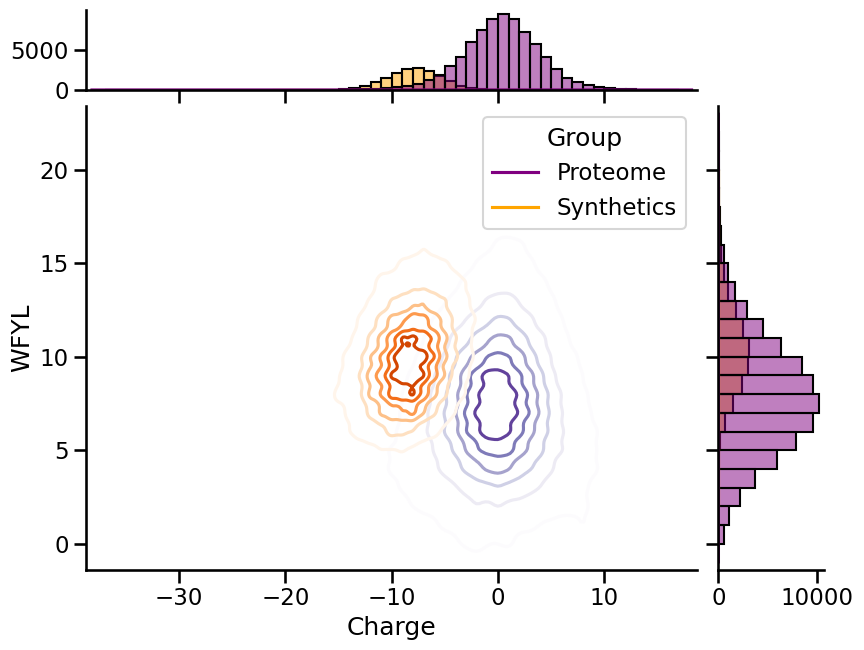

In [24]:
# 1. Before overlaying activity
make_jointplot(all_tiles, tiled_proteome, synthetic_seqs,
               output_path, "proteome_heatmap_with_marginals.png",
               show_kdes=True, show_heatmap=False)

/opt/anaconda3/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'lw'
  cset = contour_func(
/opt/anaconda3/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'lw'
  cset = contour_func(


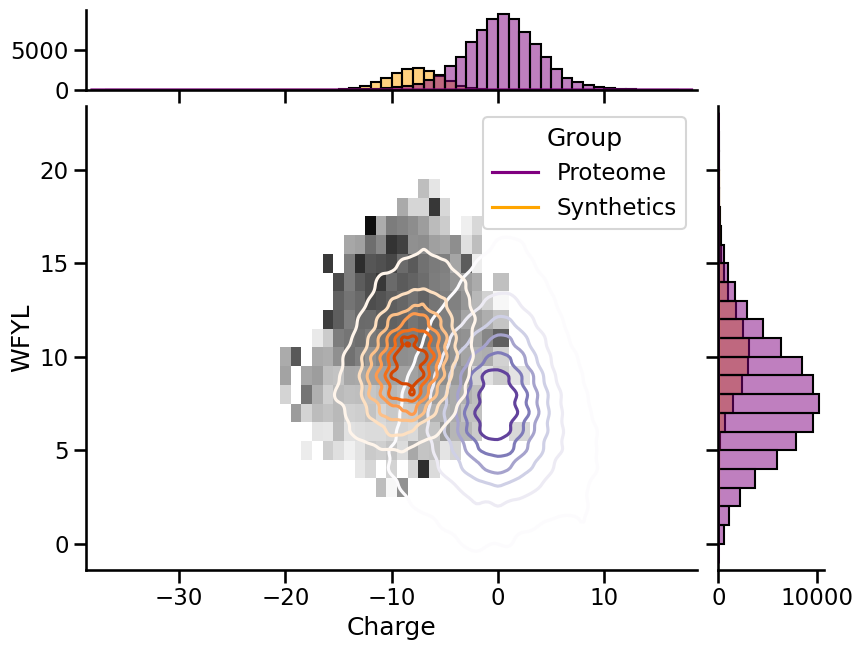

In [25]:

# 2. With activity behind
make_jointplot(all_tiles, tiled_proteome, synthetic_seqs,
               output_path, "proteome_heatmap_with_marginals_and_activity.png",
               show_kdes=True, show_heatmap=True)

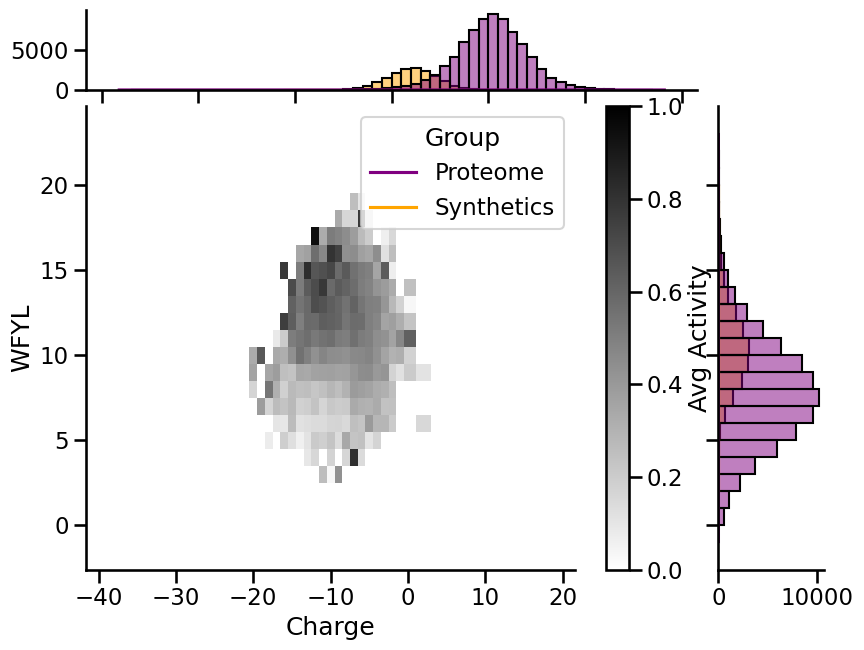

In [23]:

# 3. Activity only (use to generate colorbar)
make_jointplot(all_tiles, tiled_proteome, synthetic_seqs,
               output_path, "proteome_heatmap_with_marginals_and_activity_colorbar.png",
               show_kdes=False, show_heatmap=True, add_colorbar=True)